In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/HackathonDataset/Dataset.zip" -d "/content/dataset"

In [5]:
# !pip install tensorflow opencv-python numpy pandas matplotlib scikit-learn pillow tf2onnx

In [7]:
#for resnet
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

# Import Libraries
import tf2onnx
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
# Set Paths (Change this to correct path If required)
TRAIN_PATH = "/content/dataset/Dataset/train"
TEST_PATH = "/content/dataset/Dataset/test"
VAL_PATH = "/content/dataset/Dataset/val"

In [9]:
# Image Data Generators for Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)  # No augmentation for validation & test

In [10]:
# Load Train Data
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"]  # Force correct order
)

# Load Validation Data
val_data = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"]  # Force correct order
)

# Load Test Data
test_data = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"],  # Force correct order
    shuffle=False  # Keep order for evaluation
)

Found 20513 images belonging to 3 classes.
Found 2563 images belonging to 3 classes.
Found 2567 images belonging to 3 classes.


In [11]:
# Load Pretrained ResNet50 Model (Without Top Layers)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Unfreeze last few layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add Custom Classification Layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation="softmax")(x)  # 3 Classes: Recyclable, Non-Recyclable, Biodegradable

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [12]:
# Compile Model
resnet_model = Model(inputs=base_model.input, outputs=output_layer)
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

In [13]:
# Define Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6)

In [14]:
# Train ResNet Model
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 408s 533ms/step - accuracy: 0.6946 - loss: 0.6682 - val_accuracy: 0.6785 - val_loss: 0.8410 - learning_rate: 1.0000e-05
Epoch 2/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 311s 485ms/step - accuracy: 0.9478 - loss: 0.1488 - val_accuracy: 0.9805 - val_loss: 0.0561 - learning_rate: 1.0000e-05
Epoch 3/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 314s 489ms/step - accuracy: 0.9654 - loss: 0.0957 - val_accuracy: 0.9840 - val_loss: 0.0462 - learning_rate: 1.0000e-05
Epoch 4/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 313s 488ms/step - accuracy: 0.9771 - loss: 0.0650 - val_accuracy: 0.9856 - val_loss: 0.0432 - learning_rate: 1.0000e-05
Epoch 5/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 312s 486ms/step - accuracy: 0.9845 - loss: 0.0470 - val_accuracy: 0.9895 - val_loss: 0.0300 - learning_rate: 1.0000e-05
Epoch 6/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 319s 497ms/step - accuracy: 0.9885 - loss: 0.0371 - val_accuracy: 0.9863 - val_loss: 0.0401 - learning_rate: 1.0000e-05
Epoch 7/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
# Save ResNet Model
resnet_model.save("waste_classifier_resnet.keras")

In [17]:
# Model Evaluation on Test Data
test_loss, test_acc = resnet_model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.9830 - loss: 0.0535
Test Accuracy: 0.9871


In [18]:
# Generate Classification Report
y_pred = resnet_model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=test_data.class_indices.keys()))

81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step
Classification Report:
                 precision    recall  f1-score   support

    recyclable       0.99      0.98      0.98       835
non_recyclable       0.98      0.99      0.98       895
 biodegradable       1.00      1.00      1.00       837

      accuracy                           0.99      2567
     macro avg       0.99      0.99      0.99      2567
  weighted avg       0.99      0.99      0.99      2567



In [19]:
print(train_data.class_indices)

{'recyclable': 0, 'non_recyclable': 1, 'biodegradable': 2}


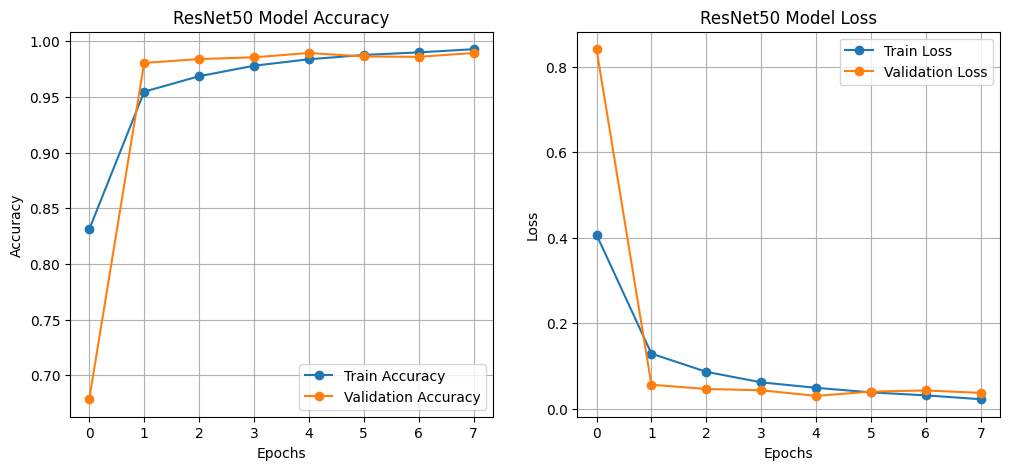

In [21]:
# Plot Accuracy & Loss for ResNet50
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history["accuracy"], label="Train Accuracy", marker='o')
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy", marker='o')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ResNet50 Model Accuracy")
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history["loss"], label="Train Loss", marker='o')
plt.plot(history_resnet.history["val_loss"], label="Validation Loss", marker='o')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ResNet50 Model Loss")
plt.grid(True)

plt.show()

In [22]:
# Load Trained Model
model = tf.keras.models.load_model("/content/waste_classifier_resnet.keras")

In [23]:
# Define Class Labels (Same as Dataset Folder Names)
CLASS_NAMES = ["Recyclable", "Non-Recyclable", "Biodegradable"]

In [24]:
# Function to Predict Waste Category
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Resize
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Prediction: {CLASS_NAMES[class_index]} (Confidence: {confidence:.2f})")

In [26]:
# Test with a Sample Image
predict_image("/content/WhatsApp Image 2025-02-14 at 19.17.35_1d1d711a.jpg")  # Change this to an actual image path

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: Non-Recyclable (Confidence: 0.80)


**Bert model Training**

In [1]:
!pip install pandas torch transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

In [ ]:
# Load dataset
df = pd.read_csv("/content/waste_classification_dataset.csv")

In [ ]:
# Map categories to numbers
label_map = {"Recyclable": 0, "Non-Recyclable": 1, "Biodegradable": 2}
df["label"] = df["waste_category"].map(label_map)

In [ ]:
# Load BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
# Custom Dataset Class
class WasteDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        inputs = tokenizer(self.texts[idx], padding="max_length", truncation=True, return_tensors="pt")
        inputs["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return inputs

In [ ]:
# Prepare Dataset
dataset = WasteDataset(df["text"].tolist(), df["label"].tolist())

In [ ]:
# Load Pretrained BERT Model for Classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

In [ ]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="./bert_waste_model",
    per_device_train_batch_size=4,
    num_train_epochs=5,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
)

In [ ]:
# Trainer for BERT Model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)

In [ ]:
# Train the Model
trainer.train()

In [ ]:
# Save Fine-Tuned Model
model.save_pretrained("bert_waste_classifier")
tokenizer.save_pretrained("bert_waste_classifier")